<a href="https://colab.research.google.com/github/SheKJana/first-own-repository/blob/main/alleBilder_aufsteigende_Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Mit komplettem Datensatz aber alten Architektur mit aufsteigenden Filter**

**Daten & Splits**

Bildgröße: 128×128 (Stellschraube: 160/192 für mehr Details).
Batch-Größe: 32 (Stellschraube: 16–64 je nach Speicher).
Validation-Anteil: 20 % aus dem Trainingsordner.
Fester Seed: 123 (reproduzierbare Splits/Runs).

**Bild-Augmentationen (mit Stärke) **

Horizontal spiegeln (RandomFlip("horizontal")).
Drehen bis ca. ±20 % (RandomRotation(0.2)).
Verschieben ±5 % in x/y (RandomTranslation(0.05, 0.05)).
Zoomen ±10 % (RandomZoom(0.1)).
Kontrast ±10 % (RandomContrast(0.1)).
Stellschrauben: Rotations-/Translations-/Zoom-/Kontrast-Stärken anpassen; Bildgröße erhöhen.

**Modellarchitektur (kompakt)**

Conv-Blöcke: 64 → 32 → 16 Filter, jeweils 3×3 + MaxPooling.
Dense: 128 → Dropout(0.25) → 64.
Ausgang: Logits (ohne Softmax) für saubere Kalibrierung.
Stellschrauben: Filterzahlen, zusätzliche Conv-Stufe, Dropout (0.15–0.5).

**Training**

Optimierer: Adam (Standard-LR).
Verlust: SparseCategoricalCrossentropy(from_logits=True, label_smoothing=0.05).
Klassen­gewichte: inverse Häufigkeit (balanciert seltene Klassen).
Callbacks: EarlyStopping(patience=25, monitor='val_accuracy', restore_best_weights=True),
ReduceLROnPlateau(factor=0.5, patience=8, min_lr=1e-5).
Epochen-Budget: bis 100.
Stellschrauben: label_smoothing, Geduld-Werte, LR-Reduktion, Batch-Größe.

**Kalibrierung & Verlässlichkeit**

Temperature Scaling auf Validation (T via Adam, ~300 Schritte, LR 0.01).
ECE (Expected Calibration Error) zur Plausibilitätsprüfung.
Stellschrauben: Iterationszahl/LR beim T-Fit, optional Reliability-Diagramm.

**Auswertung (Test)**

Kennzahlen: Test-Accuracy, zeilen-normierte Confusion-Matrix,
PR/ROC der 3 schwächsten Klassen, Wilson-CIs je Klasse.

**Entscheidungslogik (Validation → Test)**

Schwellen-Suche auf Validation:
– Summen-Schwelle Top-1+Top-2 innerhalb derselben Frucht: Raster 0.94–0.995.
– Qualitäts-Schwelle Top-1: Raster 0.85–0.95.
– Nebenbedingungen für Kandidaten: sehr wenig Fruchtfehler und moderater Manuell-Anteil.

Beste Schwellen einmal festlegen, dann unverändert auf Test berichten.

Stellschrauben: Suchraster enger/weiter, Nebenbedingungen (Fehler-/Manuell-Grenzen).

In [14]:
# Block 1 — Pakete laden und Zufall fixieren: sorgt für vergleichbare Ergebnisse
from pathlib import Path
import os, random, hashlib, json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, roc_curve, auc
from statsmodels.stats.proportion import proportion_confint
import matplotlib.pyplot as plt

SEED = 123
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
plt.rcParams['figure.dpi'] = 120


In [15]:
# Block 2 — Drive verbinden & Pfade prüfen
# Kurz: Mountet Google Drive (erzwingt Verbindung), setzt BASE/Train/Test/Split und prüft die Struktur kompakt.

from pathlib import Path
import os

# 2.1 Drive-Mount robust erzwingen (idempotent)
try:
    from google.colab import drive  # läuft nur in Colab
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive', force_remount=True)
except Exception as e:
    raise RuntimeError("Google Drive konnte nicht gemountet werden. Läuft das Notebook in Google Colab?") from e

# 2.2 Datensatz wählen (hier: ursprüngliches Set)
BASE = Path("/content/drive/MyDrive/fruits_baum_split")
TRAIN_DIR = BASE / "train"
TEST_DIR  = BASE / "test"
SPLIT_XLSX = BASE / "train_test_split.xlsx"

# 2.3 Plausibilitätschecks mit klaren Meldungen
assert TRAIN_DIR.exists() and any(TRAIN_DIR.iterdir()), f"TRAIN_DIR leer/nicht vorhanden: {TRAIN_DIR}"
assert TEST_DIR.exists() and any(TEST_DIR.iterdir()),   f"TEST_DIR leer/nicht vorhanden: {TEST_DIR}"
assert SPLIT_XLSX.exists(),                             f"Split-Excel fehlt: {SPLIT_XLSX}"

print("✅ Struktur gefunden:")
print("  BASE:", BASE)
print("   ↳", TRAIN_DIR)
print("   ↳", TEST_DIR)
print("   ↳", SPLIT_XLSX.name)


Mounted at /content/drive
✅ Struktur gefunden:
  BASE: /content/drive/MyDrive/fruits_baum_split
   ↳ /content/drive/MyDrive/fruits_baum_split/train
   ↳ /content/drive/MyDrive/fruits_baum_split/test
   ↳ train_test_split.xlsx


In [16]:
# Block 3 — Aufteilung zeigen, Klassen zählen, Leckagen (Doppelnamen) verhindern
df_split = pd.read_excel(SPLIT_XLSX)
print("Split-Mapping (Kopf):\n", df_split.head(8))
print("\nTrain/Test-Verhältnis (aus Mapping):\n",
      df_split.groupby(["Klasse","TrainOrTest"]).size().unstack(fill_value=0))

def class_counts(root: Path):
    return pd.Series({p.name: len([f for f in p.iterdir() if f.is_file()])
                      for p in sorted(root.iterdir()) if p.is_dir()}).sort_index()

print("\nKlassenverteilung — TRAIN:\n", class_counts(TRAIN_DIR))
print("\nKlassenverteilung — TEST:\n", class_counts(TEST_DIR))

train_names = {f.name for f in TRAIN_DIR.rglob("*/*") if f.is_file()}
test_names  = {f.name for f in TEST_DIR.rglob("*/*") if f.is_file()}
intersect = train_names.intersection(test_names)
print(f"\nDuplikate (Dateiname) train∩test: {len(intersect)}")
assert len(intersect) == 0, "Gleicher Dateiname in train & test → Split korrigieren."


Split-Mapping (Kopf):
                   Dateiname  \
0           avo_bio_004.jpg   
1           avo_bio_014.jpg   
2           avo_bio_016.jpg   
3  avo_normal_038__test.jpg   
4        avo_normal_039.jpg   
5        avo_normal_040.jpg   
6        avo_normal_041.jpg   
7        avo_normal_042.jpg   

                                                Pfad      Klasse TrainOrTest  
0  /content/drive/MyDrive/fruits_baum_split/test/...     avo_bio        test  
1  /content/drive/MyDrive/fruits_baum_split/test/...     avo_bio        test  
2  /content/drive/MyDrive/fruits_baum_split/test/...     avo_bio        test  
3  /content/drive/MyDrive/fruits_baum_split/test/...  avo_normal        test  
4  /content/drive/MyDrive/fruits_baum_split/test/...  avo_normal        test  
5  /content/drive/MyDrive/fruits_baum_split/test/...  avo_normal        test  
6  /content/drive/MyDrive/fruits_baum_split/test/...  avo_normal        test  
7  /content/drive/MyDrive/fruits_baum_split/test/...  avo_normal 

In [27]:
# Block 3c — Vergleichstabelle: zeigt pro Klasse die Anzahl Bilder in TRAIN (verwendet), VALIDATION (verwendet) und TEST sowie die Ordner-Gesamtzahl aus TRAIN.
# Zweck: Eine klare Tabelle für den Bericht/Screenshot – leicht vergleichbar zwischen Splits.

import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path

# Sicherstellen, dass Basis-Parameter vorhanden sind (fallen sonst auf eure Standardwerte zurück)
SEED = SEED if 'SEED' in globals() else 123
image_size = image_size if 'image_size' in globals() else (128,128)
batch_size = batch_size if 'batch_size' in globals() else 32
val_split = val_split if 'val_split' in globals() else 0.2

# 1) Datasets ohne Shuffle neu laden (nur zum Zählen), damit die Verteilung exakt den verwendeten Splits entspricht
train_used_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=val_split, subset="training", seed=SEED,
    image_size=image_size, batch_size=batch_size, shuffle=False
)
val_used_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=val_split, subset="validation", seed=SEED,
    image_size=image_size, batch_size=batch_size, shuffle=False
)
test_used_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=image_size, batch_size=batch_size, shuffle=False
)

class_names = train_used_ds.class_names
num_classes = len(class_names)
name_to_idx = {c:i for i,c in enumerate(class_names)}

# 2) Helfer zum Zählen der Labels in einem tf.data-Dataset
def count_labels(ds, k):
    counts = np.zeros(k, dtype=int)
    for _, y in ds:
        y = y.numpy()
        # y ist (batch,), enthält Integer-Klassen
        binc = np.bincount(y, minlength=k)
        counts[:len(binc)] += binc
    return counts

train_used_counts = count_labels(train_used_ds, num_classes)
val_used_counts   = count_labels(val_used_ds,   num_classes)
test_counts       = count_labels(test_used_ds,  num_classes)

# 3) Ordner-Gesamtzahl pro Klasse in TRAIN (für Transparenz)
def class_counts_in_dir(root: Path):
    return pd.Series({
        p.name: len([f for f in p.iterdir() if f.is_file()])
        for p in sorted(root.iterdir()) if p.is_dir()
    }).sort_index()

train_folder_total = class_counts_in_dir(TRAIN_DIR).reindex(class_names).fillna(0).astype(int).values

# 4) Tabelle bauen (Zeilen: Klassen; Spalten: verwendete Splits + Ordner-Gesamt)
df_split_overview = pd.DataFrame({
    "TRAIN (verwendet)": train_used_counts,
    "VALIDATION (verwendet)": val_used_counts,
    "TEST": test_counts,
    "TRAIN-Ordner gesamt": train_folder_total
}, index=class_names)

# 5) Totalsumme (letzte Zeile)
totals = df_split_overview.sum(axis=0).rename("TOTAL")
df_split_overview = pd.concat([df_split_overview, totals.to_frame().T])

# 6) Schön anzeigen (geeignet für Screenshot)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
display(df_split_overview.astype(int).style.set_table_styles([
    {"selector": "th", "props": [("text-align", "left")]},
    {"selector": "td", "props": [("text-align", "right")]}
]).set_properties(**{"text-align": "right"}))


Found 235 files belonging to 10 classes.
Using 188 files for training.
Found 235 files belonging to 10 classes.
Using 47 files for validation.
Found 91 files belonging to 10 classes.


,TRAIN (verwendet),VALIDATION (verwendet),TEST,TRAIN-Ordner gesamt
avo_bio,12,0,3,12
avo_normal,39,0,36,39
banane_extra,37,0,9,37
banane_normal,11,0,2,11
citron_bio,12,0,3,12
citron_normal,42,0,10,42
mango_extra,21,0,5,21
mango_normal,14,2,4,16
süssK_bio,0,13,3,13
süssK_normal,0,32,16,32


In [17]:
# Block 4 — Datensätze laden und für flüssiges Training vorbereiten
image_size = (128, 128)   # bei Bedarf erhöhen (mehr Details, längeres Training)
batch_size = 32
val_split = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=val_split, subset="training", seed=SEED,
    image_size=image_size, batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=val_split, subset="validation", seed=SEED,
    image_size=image_size, batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=image_size, batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Klassen:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(512, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


Found 235 files belonging to 10 classes.
Using 188 files for training.
Found 235 files belonging to 10 classes.
Using 47 files for validation.
Found 91 files belonging to 10 classes.
Klassen: ['avo_bio', 'avo_normal', 'banane_extra', 'banane_normal', 'citron_bio', 'citron_normal', 'mango_extra', 'mango_normal', 'süssK_bio', 'süssK_normal']


In [18]:
# Block 5 — Früchte-Familien bilden: Qualitätsstufen derselben Frucht zusammenfassen
import numpy as np

def fruit_groups_from_prefix(class_names):
    groups = {}
    for idx, name in enumerate(class_names):
        key = name.split('_', 1)[0] if '_' in name else name
        groups.setdefault(key, []).append(idx)
    return groups

FRUIT_GROUPS = fruit_groups_from_prefix(class_names)
FRUIT_NAMES  = list(FRUIT_GROUPS.keys())
FRUIT_OF_FINE = np.zeros(len(class_names), dtype=int)
for fi, (_, idxs) in enumerate(FRUIT_GROUPS.items()):
    for j in idxs:
        FRUIT_OF_FINE[j] = fi

print("Frucht-Gruppen:", {k:[class_names[i] for i in v] for k,v in FRUIT_GROUPS.items()})


Frucht-Gruppen: {'avo': ['avo_bio', 'avo_normal'], 'banane': ['banane_extra', 'banane_normal'], 'citron': ['citron_bio', 'citron_normal'], 'mango': ['mango_extra', 'mango_normal'], 'süssK': ['süssK_bio', 'süssK_normal']}


In [19]:
# Block 6 — Kompaktes Modell mit alltagsnahen Bildvariationen
image_shape = (*image_size, 3)

def make_model(dropout=0.25):
    x_in = layers.Input(shape=image_shape)
    x = layers.Rescaling(1./255)(x_in)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomTranslation(0.05, 0.05)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.1)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    logits = layers.Dense(num_classes, activation=None, name='logits')(x)
    return tf.keras.Model(x_in, logits, name='FruitClassifier')

model = make_model(dropout=0.25)
model.summary()


Model: "FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 128, 128, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,202 (2.13 MB)

 Trainable params: 558,202 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Block 7 — Training: klare Namen im Log (trefferquote / val_trefferquote), sonst identische Parameter
from tensorflow.keras import optimizers, callbacks
import tensorflow as tf
import pandas as pd
from pathlib import Path

# Stabiler Loss mit manuellem Label-Smoothing auf sparse Labels und Logits (wie zuvor)
label_smoothing = 0.05
num_classes_tf = tf.constant(num_classes, dtype=tf.float32)

def smoothed_sparse_ce(y_true, y_pred):
    # y_true: (batch,) Integer-Labels; y_pred: (batch, num_classes) Logits
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    y_true_oh = tf.one_hot(y_true, depth=num_classes)
    eps = tf.constant(label_smoothing, tf.float32)
    y_true_smooth = (1.0 - eps) * y_true_oh + eps / num_classes_tf
    loss_vec = tf.nn.softmax_cross_entropy_with_logits(labels=y_true_smooth, logits=y_pred)
    return tf.reduce_mean(loss_vec)

# ➜ WICHTIG: Metrik-Name auf „trefferquote“ setzen → Logs zeigen „trefferquote“ / „val_trefferquote“
model.compile(
    optimizer=optimizers.Adam(),
    loss=smoothed_sparse_ce,
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='trefferquote')]
)

# Klassenverteilung aus Dateien bestimmen (für class_weight) – unverändert
def class_counts(root: Path):
    return pd.Series({
        p.name: len([f for f in p.iterdir() if f.is_file()])
        for p in sorted(root.iterdir()) if p.is_dir()
    }).sort_index()

train_count = class_counts(TRAIN_DIR)
class_weight = {
    i: float(train_count.sum() / (len(train_count) * train_count[class_names[i]]))
    for i in range(num_classes)
}

# Callbacks: Monitor jetzt auf „val_trefferquote“ (klar verständlich), Rest unverändert
early_stop = callbacks.EarlyStopping(
    monitor='val_trefferquote',
    patience=25,
    restore_best_weights=True,
    mode='max'
)
reduce_lr  = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight,
    verbose=1
)


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 140s 7s/step - loss: 2.2222 - trefferquote: 0.1036 - val_loss: 2.2342 - val_trefferquote: 0.1064 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 2.2102 - trefferquote: 0.1986 - val_loss: 2.2350 - val_trefferquote: 0.1064 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - loss: 2.1337 - trefferquote: 0.2679 - val_loss: 2.2543 - val_trefferquote: 0.2340 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - loss: 2.0361 - trefferquote: 0.2887 - val_loss: 2.2215 - val_trefferquote: 0.2979 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 2.0340 - trefferquote: 0.3243 - val_loss: 2.1682 - val_trefferquote: 0.2340 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 1.9103 - trefferquote: 0.3823 - val_loss: 2.2188 - val_trefferquote: 0.2128 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 1.7

Kalibrierung (Validation): T=0.489 | ECE=0.0746


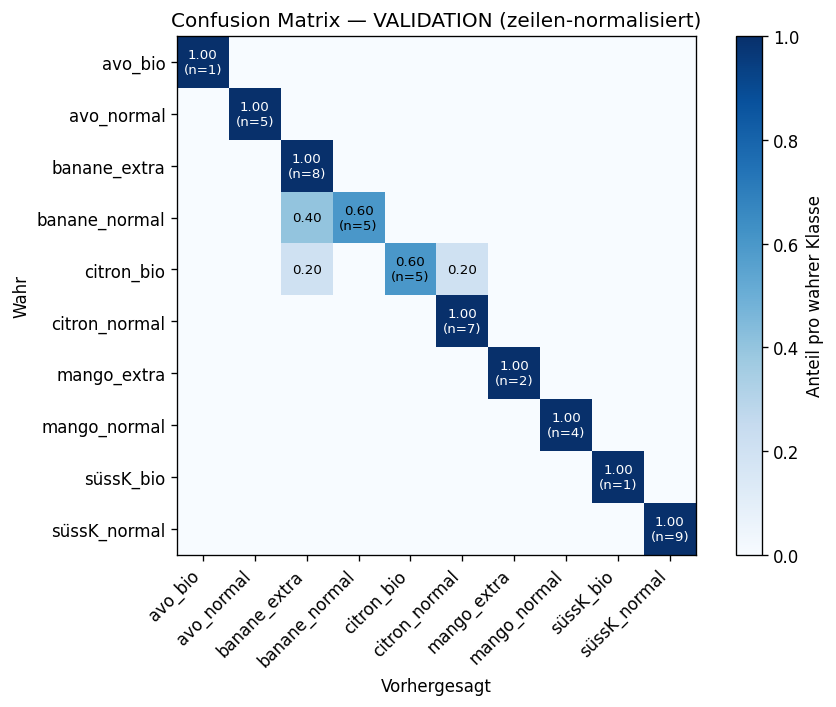

In [21]:
# Block 8 — Kalibrierung (Validation), ECE und Confusion-Matrix im einheitlichen Stil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix

def plot_cm_row_normalized(y_true, y_pred, class_names, title):
    num_classes = len(class_names)
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
    row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
    cmn = cm / row_sums

    plt.figure(figsize=(8,6))
    plt.imshow(cmn, vmin=0, vmax=1, cmap="Blues", aspect='equal')
    plt.colorbar(label="Anteil pro wahrer Klasse")
    plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
    plt.yticks(range(num_classes), class_names)
    plt.xlabel("Vorhergesagt")
    plt.ylabel("Wahr")
    plt.title(title)
    for i in range(num_classes):
        for j in range(num_classes):
            if cm[i, j] == 0:
                continue
            txt = f"{cmn[i,j]:.2f}" if i != j else f"{cmn[i,j]:.2f}\n(n={int(row_sums[i,0])})"
            plt.text(j, i, txt, ha='center', va='center',
                     color=("white" if cmn[i,j] >= 0.7 else "black"), fontsize=8)
    plt.tight_layout()
    plt.show()

def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

# Validation-Logits/Labels sammeln
val_logits, val_labels = [], []
for xb, yb in val_ds:
    lg = model.predict(xb, verbose=0)
    val_logits.append(lg)
    val_labels.append(yb.numpy())
val_logits = np.concatenate(val_logits, 0)
val_labels = np.concatenate(val_labels, 0)

# Temperature-Scaling fitten (keine Hyperparameter-Änderung)
def fit_temperature(val_logits, val_labels, iters=300, lr=0.01):
    T = tf.Variable(1.0)
    x = tf.constant(val_logits, dtype=tf.float32)
    y = tf.constant(val_labels, dtype=tf.int32)
    opt = tf.keras.optimizers.Adam(lr)
    for _ in range(iters):
        with tf.GradientTape() as g:
            loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(y, tf.nn.softmax(x / T))
            )
        opt.apply_gradients([(g.gradient(loss, T), T)])
    return float(T.numpy())

T = fit_temperature(val_logits, val_labels)

def apply_T(logits, T):
    return softmax_np(logits / T)

val_probs = apply_T(val_logits, T)
val_pred  = val_probs.argmax(axis=1)

# ECE (nur Zahlenausgabe, keine Stiländerung erforderlich)
def ece(probs, labels, n_bins=10):
    confid = probs.max(axis=1); preds = probs.argmax(axis=1); accs = (preds == labels).astype(float)
    bins = np.linspace(0,1,n_bins+1); e = 0.0
    for i in range(n_bins):
        m = (confid > bins[i]) & (confid <= bins[i+1])
        if m.any():
            e += abs(confid[m].mean() - accs[m].mean()) * m.mean()
    return e

print(f"Kalibrierung (Validation): T={T:.3f} | ECE={ece(val_probs, val_labels):.4f}")

# Validierungs-CM im einheitlichen Stil
plot_cm_row_normalized(val_labels, val_pred, class_names, "Confusion Matrix — VALIDATION (zeilen-normalisiert)")


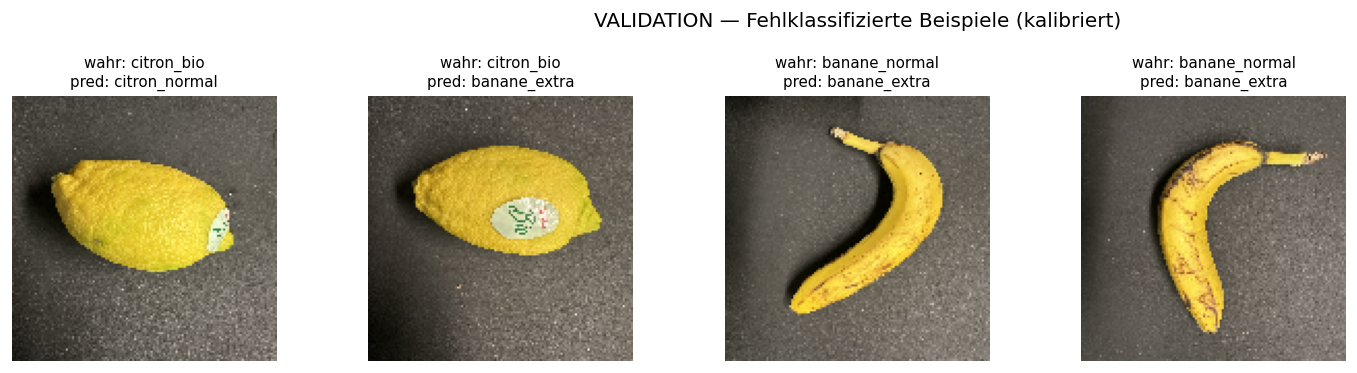

In [22]:
# Block 8A — Validation: fehlklassifizierte Bilder mit wahrem & vorhergesagtem Label (kalibriert)
import numpy as np
import matplotlib.pyplot as plt

wrong_imgs_v, wrong_true_v, wrong_pred_v = [], [], []

for xb, yb in val_ds:
    logits_b = model.predict(xb, verbose=0)
    probs_b  = apply_T(logits_b, T)       # T und apply_T aus Block 8
    preds_b  = np.argmax(probs_b, axis=1)
    mism     = preds_b != yb.numpy()
    if np.any(mism):
        wrong_imgs_v.append(xb.numpy()[mism])
        wrong_true_v.extend(yb.numpy()[mism])
        wrong_pred_v.extend(preds_b[mism])

if wrong_imgs_v:
    wrong_imgs_v = np.concatenate(wrong_imgs_v, axis=0)
    n = len(wrong_imgs_v)
    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(wrong_imgs_v[i].astype("uint8"))
        t = class_names[int(wrong_true_v[i])]
        p = class_names[int(wrong_pred_v[i])]
        ax.set_title(f"wahr: {t}\npred: {p}", fontsize=9)
        ax.axis("off")
    plt.suptitle("VALIDATION — Fehlklassifizierte Beispiele (kalibriert)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("VALIDATION: keine Fehlklassifikationen gefunden.")


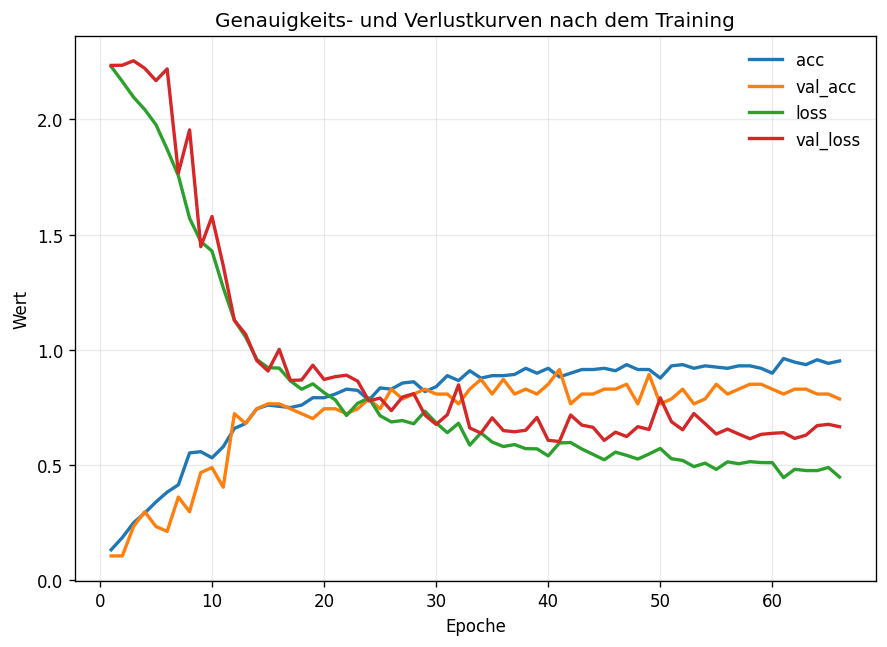

In [28]:
# Block 8B — Trainingskurven (ein Plot mit 4 Linien)
# -> Zeigt, wie sich Trefferquote (acc/val_acc) und Fehler (loss/val_loss) über die Epochen entwickeln – wie in der Prof-Vorlage.
import matplotlib.pyplot as plt
import numpy as np
hist = history.history
acc_key     = next(k for k in ['trefferquote','sparse_categorical_accuracy','accuracy'] if k in hist)
val_acc_key = next(k for k in ['val_trefferquote','val_sparse_categorical_accuracy','val_accuracy'] if k in hist)

acc, val_acc = np.array(hist[acc_key]), np.array(hist[val_acc_key])
loss, val_loss = np.array(hist['loss']), np.array(hist['val_loss'])
epochs = np.arange(1, len(acc)+1)

plt.figure(figsize=(7.5,5.5))
plt.plot(epochs, acc, label='acc', linewidth=2)
plt.plot(epochs, val_acc, label='val_acc', linewidth=2)
plt.plot(epochs, loss, label='loss', linewidth=2)
plt.plot(epochs, val_loss, label='val_loss', linewidth=2)
plt.xlabel('Epoche'); plt.ylabel('Wert')
plt.title('Genauigkeits- und Verlustkurven nach dem Training')
plt.grid(True, alpha=0.25); plt.legend(frameon=False); plt.tight_layout(); plt.show()


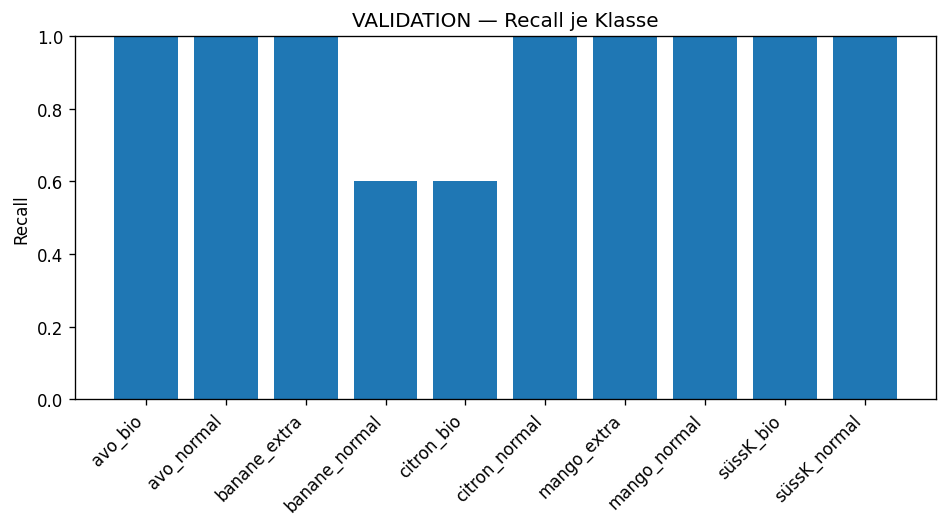

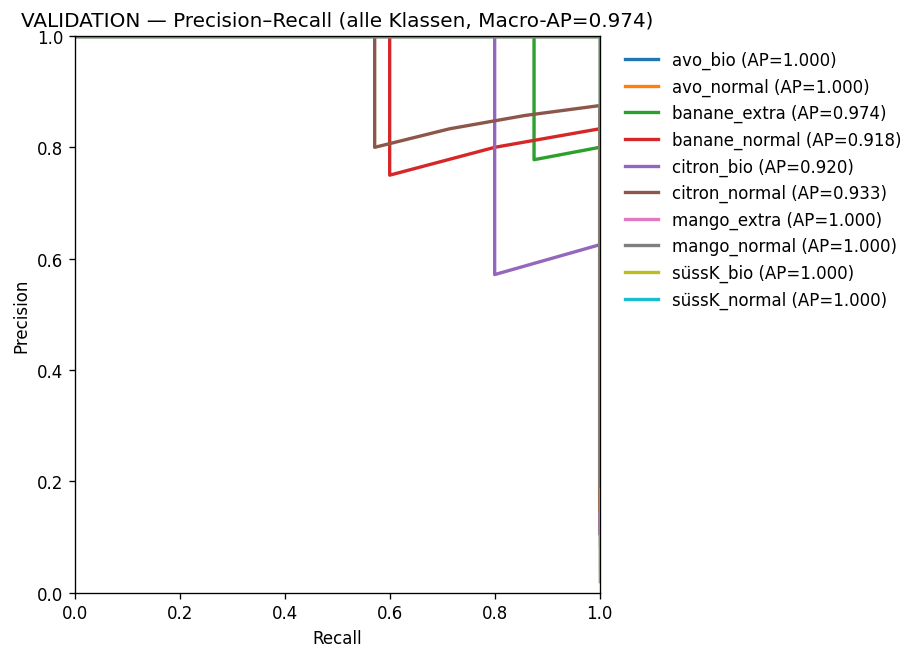

In [31]:
# Block 8C — VALIDATION: Recall je Klasse + Precision–Recall-Kurven für ALLE Klassen
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc

# Vorhersagen (kalibriert)
val_logits, val_labels = [], []
for xb, yb in val_ds:
    val_logits.append(model.predict(xb, verbose=0))
    val_labels.append(yb.numpy())
val_logits = np.concatenate(val_logits, 0)
val_labels = np.concatenate(val_labels, 0)
val_probs  = apply_T(val_logits, T)
val_pred   = val_probs.argmax(axis=1)

# Recall je Klasse (Balken)
cm_v = confusion_matrix(val_labels, val_pred, labels=np.arange(len(class_names)))
support_v = cm_v.sum(axis=1).clip(min=1)
recall_v = (cm_v.diagonal() / support_v).astype(float)

plt.figure(figsize=(8,4.5))
plt.bar(range(len(class_names)), recall_v)
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0,1); plt.ylabel('Recall'); plt.title('VALIDATION — Recall je Klasse')
plt.tight_layout(); plt.show()

# Precision–Recall für ALLE Klassen (+ Macro-AP)
y_true_oh = np.eye(len(class_names))[val_labels]
plt.figure(figsize=(7.8,5.6))
ap_list = []
for i in range(len(class_names)):
    p, r, _ = precision_recall_curve(y_true_oh[:, i], val_probs[:, i])
    ap = auc(r, p) if len(r) > 1 else 0.0
    ap_list.append(ap)
    plt.plot(r, p, linewidth=2, label=f"{class_names[i]} (AP={ap:.3f})")
macro_ap = float(np.mean(ap_list)) if ap_list else 0.0
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"VALIDATION — Precision–Recall (alle Klassen, Macro-AP={macro_ap:.3f})")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", frameon=False, ncol=1)
plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout(); plt.show()


TEST: Accuracy=82.42%

Klassifikationsreport (TEST):
               precision    recall  f1-score   support

      avo_bio       0.17      0.67      0.27         3
   avo_normal       0.92      0.67      0.77        36
 banane_extra       0.75      1.00      0.86         9
banane_normal       1.00      0.50      0.67         2
   citron_bio       1.00      1.00      1.00         3
citron_normal       1.00      1.00      1.00        10
  mango_extra       1.00      1.00      1.00         5
 mango_normal       1.00      1.00      1.00         4
   süssK_bio       1.00      0.33      0.50         3
süssK_normal       0.94      1.00      0.97        16

     accuracy                           0.82        91
    macro avg       0.88      0.82      0.80        91
 weighted avg       0.91      0.82      0.84        91



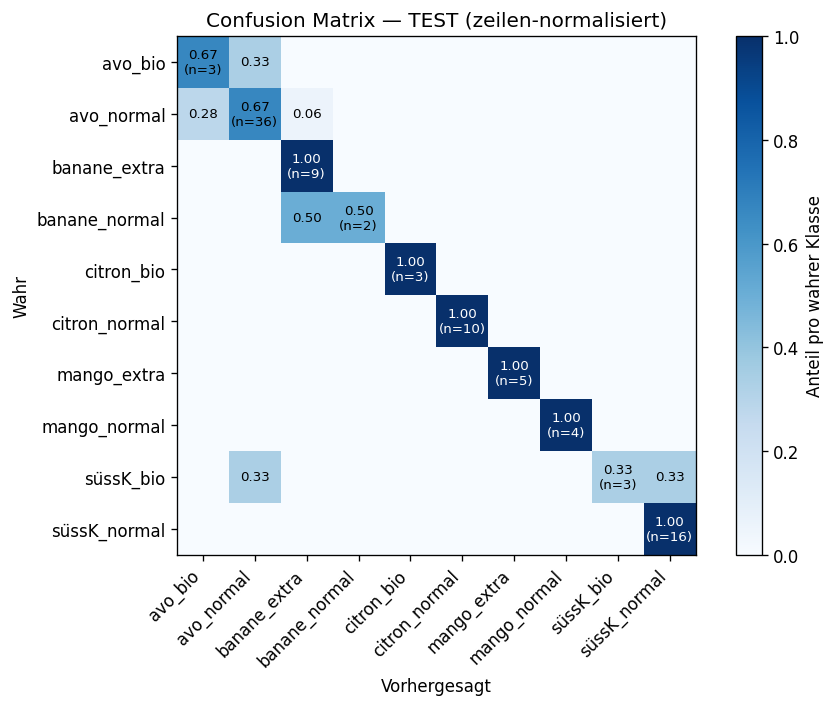

In [23]:
# Block 9 — Test: Accuracy, Klassifikationsreport und Confusion-Matrix im einheitlichen Stil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Testvorhersagen (mit Kalibrierung aus Block 8)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
y_true_t   = np.concatenate([y.numpy() for _, y in test_ds], 0)
y_logits_t = model.predict(test_ds, verbose=0)
y_prob_t   = apply_T(y_logits_t, T)
y_pred_t   = y_prob_t.argmax(axis=1)

print(f"TEST: Accuracy={test_acc:.2%}")
print("\nKlassifikationsreport (TEST):")
print(classification_report([class_names[i] for i in y_true_t],
                            [class_names[i] for i in y_pred_t],
                            zero_division=0))

# Hilfsfunktion hier erneut definieren, damit der Block unabhängig lauffähig ist
def plot_cm_row_normalized(y_true, y_pred, class_names, title):
    num_classes = len(class_names)
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
    row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
    cmn = cm / row_sums

    plt.figure(figsize=(8,6))
    plt.imshow(cmn, vmin=0, vmax=1, cmap="Blues", aspect='equal')
    plt.colorbar(label="Anteil pro wahrer Klasse")
    plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
    plt.yticks(range(num_classes), class_names)
    plt.xlabel("Vorhergesagt")
    plt.ylabel("Wahr")
    plt.title(title)
    for i in range(num_classes):
        for j in range(num_classes):
            if cm[i, j] == 0:
                continue
            txt = f"{cmn[i,j]:.2f}" if i != j else f"{cmn[i,j]:.2f}\n(n={int(row_sums[i,0])})"
            plt.text(j, i, txt, ha='center', va='center',
                     color=("white" if cmn[i,j] >= 0.7 else "black"), fontsize=8)
    plt.tight_layout()
    plt.show()

# Test-CM im einheitlichen Stil
plot_cm_row_normalized(y_true_t, y_pred_t, class_names, "Confusion Matrix — TEST (zeilen-normalisiert)")


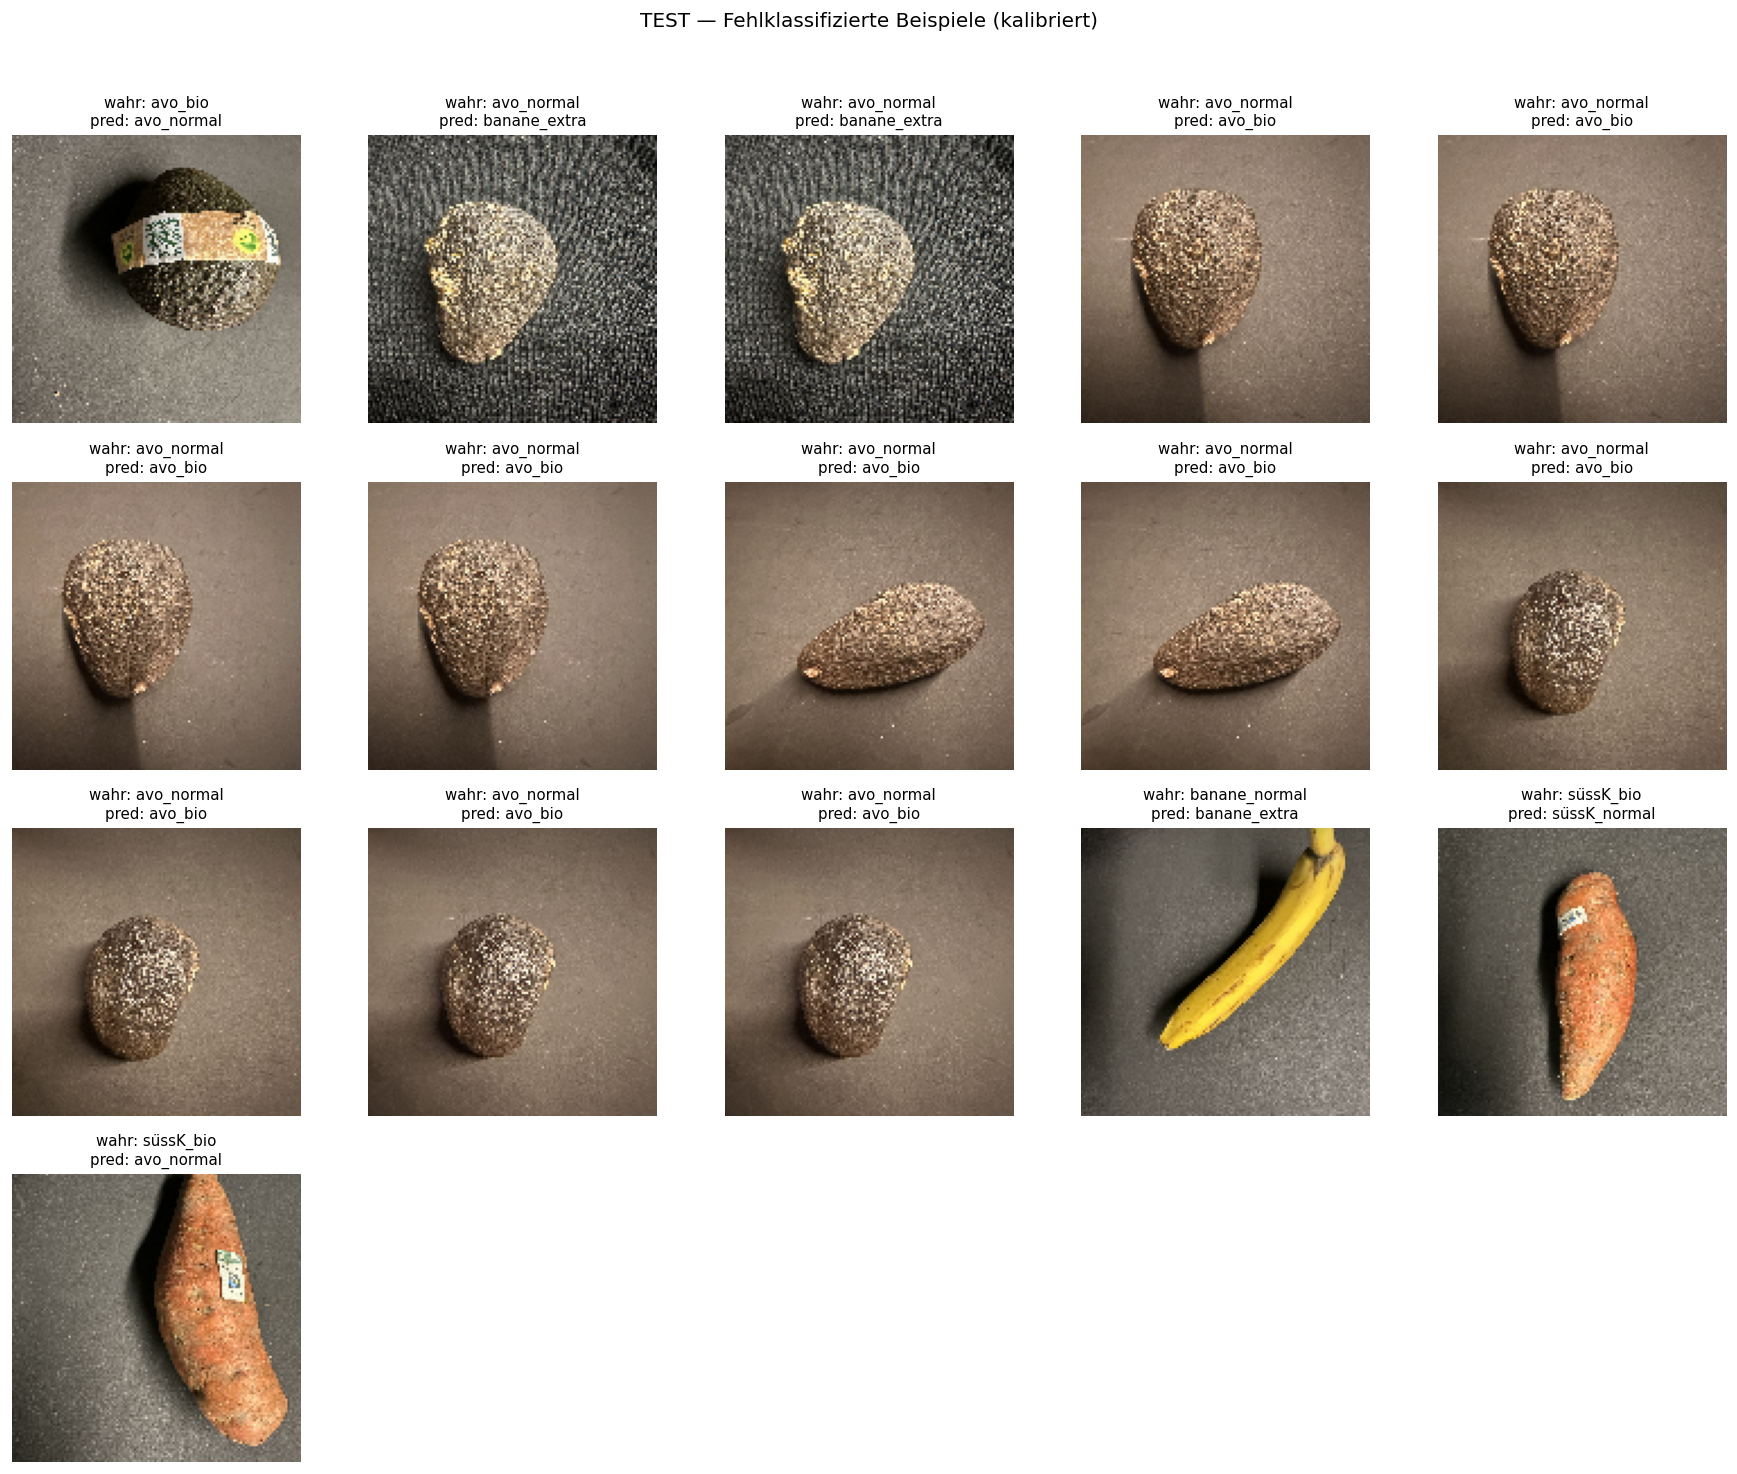

In [24]:
# Block 9A — Test: fehlklassifizierte Bilder (kalibriert) mit wahrem & vorhergesagtem Label
import numpy as np
import matplotlib.pyplot as plt

wrong_imgs_t, wrong_true_t, wrong_pred_t = [], [], []

for xb, yb in test_ds:
    logits_b = model.predict(xb, verbose=0)
    probs_b  = apply_T(logits_b, T)       # T und apply_T aus Block 8
    preds_b  = np.argmax(probs_b, axis=1)
    mism     = preds_b != yb.numpy()
    if np.any(mism):
        wrong_imgs_t.append(xb.numpy()[mism])
        wrong_true_t.extend(yb.numpy()[mism])
        wrong_pred_t.extend(preds_b[mism])

if wrong_imgs_t:
    wrong_imgs_t = np.concatenate(wrong_imgs_t, axis=0)
    n = len(wrong_imgs_t)
    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(wrong_imgs_t[i].astype("uint8"))
        t = class_names[int(wrong_true_t[i])]
        p = class_names[int(wrong_pred_t[i])]
        ax.set_title(f"wahr: {t}\npred: {p}", fontsize=9)
        ax.axis("off")
    plt.suptitle("TEST — Fehlklassifizierte Beispiele (kalibriert)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("TEST: keine Fehlklassifikationen gefunden.")


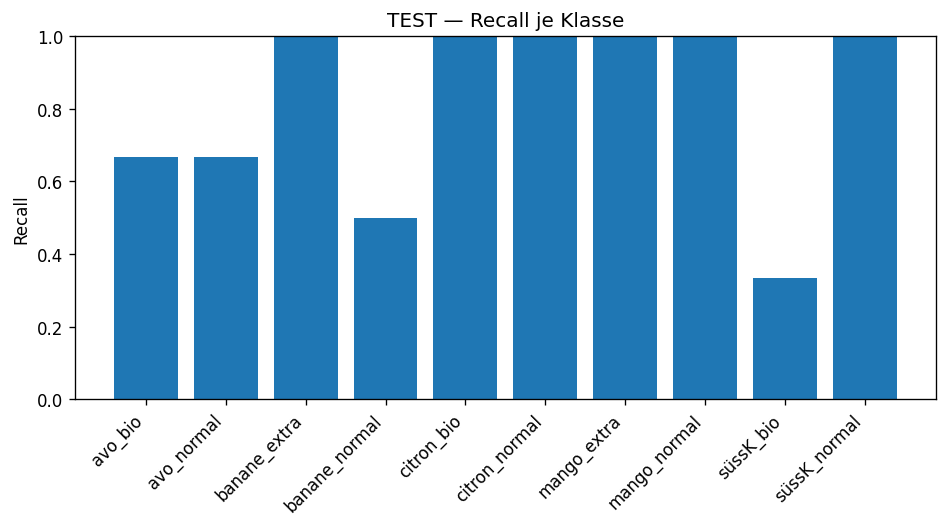

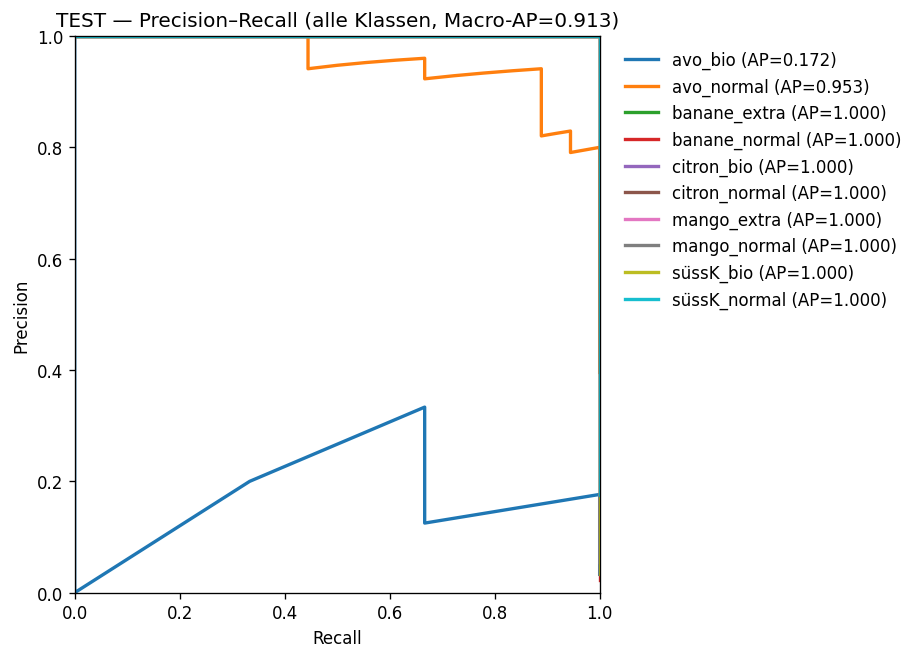

In [32]:
# Block 9B — TEST: Recall je Klasse + Precision–Recall-Kurven für ALLE Klassen
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc

# Vorhersagen (kalibriert)
try:
    y_true_t, y_prob_t  # bereits vorhanden?
except NameError:
    y_true_t = np.concatenate([y.numpy() for _, y in test_ds], 0)
    y_logits_t = model.predict(test_ds, verbose=0)
    y_prob_t   = apply_T(y_logits_t, T)
y_pred_t = y_prob_t.argmax(axis=1)

# Recall je Klasse (Balken)
cm_t = confusion_matrix(y_true_t, y_pred_t, labels=np.arange(len(class_names)))
support_t = cm_t.sum(axis=1).clip(min=1)
recall_t = (cm_t.diagonal() / support_t).astype(float)

plt.figure(figsize=(8,4.5))
plt.bar(range(len(class_names)), recall_t)
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0,1); plt.ylabel('Recall'); plt.title('TEST — Recall je Klasse')
plt.tight_layout(); plt.show()

# Precision–Recall für ALLE Klassen (+ Macro-AP)
y_true_oh_t = np.eye(len(class_names))[y_true_t]
plt.figure(figsize=(7.8,5.6))
ap_list_t = []
for i in range(len(class_names)):
    p, r, _ = precision_recall_curve(y_true_oh_t[:, i], y_prob_t[:, i])
    ap = auc(r, p) if len(r) > 1 else 0.0
    ap_list_t.append(ap)
    plt.plot(r, p, linewidth=2, label=f"{class_names[i]} (AP={ap:.3f})")
macro_ap_t = float(np.mean(ap_list_t)) if ap_list_t else 0.0
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"TEST — Precision–Recall (alle Klassen, Macro-AP={macro_ap_t:.3f})")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", frameon=False, ncol=1)
plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout(); plt.show()


In [25]:
# Block 10 — Schwellen festlegen (Validation) und fair auf Test berichten
def fruit_probs(probs_fine, groups_dict):
    return np.stack([probs_fine[:, idxs].sum(axis=1) for idxs in groups_dict.values()], axis=1)

def top2_indices(a):
    part = np.argpartition(-a, kth=1, axis=1)
    i1 = part[:,0]; i2 = part[:,1]
    v1 = a[np.arange(len(a)), i1]; v2 = a[np.arange(len(a)), i2]
    swap = v2 > v1
    i1[swap], i2[swap] = i2[swap], i1[swap]
    return i1, np.maximum(v1, v2), i2, np.minimum(v1, v2)

fruit_sum_grid = np.round(np.linspace(0.94, 0.995, 12), 3)
qual_thr_grid  = np.round(np.linspace(0.85, 0.95, 11), 2)

val_probs_fruit = fruit_probs(val_probs, FRUIT_GROUPS)
val_true_fruit  = FRUIT_OF_FINE[val_labels]
i1_fine, c1_fine, i2_fine, c2_fine = top2_indices(val_probs)
same_fruit = (FRUIT_OF_FINE[i1_fine] == FRUIT_OF_FINE[i2_fine])

candidates = []
for fruit_sum_thr in fruit_sum_grid:
    mask_fruit_auto = same_fruit & ((c1_fine + c2_fine) >= fruit_sum_thr)
    pred_fruit_auto = FRUIT_OF_FINE[i1_fine[mask_fruit_auto]]
    true_fruit_auto = val_true_fruit[mask_fruit_auto]
    fruit_err = (pred_fruit_auto != true_fruit_auto).mean() if mask_fruit_auto.any() else np.nan
    coverage_fruit = mask_fruit_auto.mean()
    for qual_thr in qual_thr_grid:
        mask_full = mask_fruit_auto & (c1_fine >= qual_thr)
        full_rate = mask_full.mean()
        manual_rate = 1.0 - coverage_fruit
        sel_acc_full = (i1_fine[mask_full] == val_labels[mask_full]).mean() if mask_full.any() else np.nan
        candidates.append({
            "fruit_sum_thr": float(fruit_sum_thr), "qual_thr": float(qual_thr),
            "fruit_auto_rate": float(coverage_fruit),
            "fruit_err_rate": float(0.0 if np.isnan(fruit_err) else fruit_err),
            "full_auto_rate": float(full_rate),
            "manual_rate": float(manual_rate),
            "sel_acc_full": float(0.0 if np.isnan(sel_acc_full) else sel_acc_full)
        })

cands = [r for r in candidates if r["fruit_err_rate"] <= 0.005 and r["manual_rate"] <= 0.10]
cands.sort(key=lambda r: (1.0 - r['manual_rate'], r['full_auto_rate']))
BEST = cands[0] if cands else sorted(
    candidates, key=lambda r: (1.0 - r['manual_rate'], -r['fruit_err_rate'], r['full_auto_rate'])
)[0]
print("Gewählte Schwellen (aus Validation):", BEST)

samefruit_sum_thr = BEST['fruit_sum_thr']
qual_thr          = BEST['qual_thr']

probs_test = y_prob_t
i1_fine_t, c1_fine_t, i2_fine_t, c2_fine_t = top2_indices(probs_test)

same_fruit_t = (FRUIT_OF_FINE[i1_fine_t] == FRUIT_OF_FINE[i2_fine_t])
sum_ok_t     = (c1_fine_t + c2_fine_t) >= samefruit_sum_thr
mask_fruit   = same_fruit_t & sum_ok_t
mask_full    = mask_fruit & (c1_fine_t >= qual_thr)

decision = np.array(["manual"]*len(y_true_t), dtype=object)
pred_fine = np.full(len(y_true_t), -1, dtype=int)
pred_fruit= np.full(len(y_true_t), -1, dtype=int)

decision[mask_full]   = "auto_full"
pred_fine[mask_full]  = i1_fine_t[mask_full]
pred_fruit[mask_full] = FRUIT_OF_FINE[i1_fine_t[mask_full]]

mask_fruit_only = mask_fruit & (c1_fine_t < qual_thr)
decision[mask_fruit_only]   = "auto_fruit_only"
for idx in np.where(mask_fruit_only)[0]:
    fr = FRUIT_OF_FINE[i1_fine_t[idx]]
    pred_fine[idx]  = min(FRUIT_GROUPS[FRUIT_NAMES[fr]])  # konservative Qualitätswahl
    pred_fruit[idx] = fr

manual_rate = (decision == "manual").mean()
auto_full_rate  = (decision == "auto_full").mean()
auto_fruit_rate = (decision == "auto_fruit_only").mean()
auto_rate       = 1 - manual_rate

auto_any = (decision != "manual")
sel_acc_full = (pred_fine[auto_any] == y_true_t[auto_any]).mean() if auto_any.any() else float('nan')
true_fruit_auto = FRUIT_OF_FINE[y_true_t[auto_any]]
pred_fruit_auto = pred_fruit[auto_any]
fruit_err = (pred_fruit_auto != true_fruit_auto).mean() if auto_any.any() else float('nan')

print(f"Policy (TEST) — Auto(voll): {auto_full_rate:.0%} | Auto(nur Frucht): {auto_fruit_rate:.0%} | Manuell: {manual_rate:.0%}")
print(f"Selektive Accuracy (alle Auto-Fälle): {sel_acc_full:.3f} | Auto-Fruchtfehler: {fruit_err:.3f}")


Gewählte Schwellen (aus Validation): {'fruit_sum_thr': 0.995, 'qual_thr': 0.85, 'fruit_auto_rate': 0.3404255319148936, 'fruit_err_rate': 0.0, 'full_auto_rate': 0.2127659574468085, 'manual_rate': 0.6595744680851063, 'sel_acc_full': 1.0}
Policy (TEST) — Auto(voll): 29% | Auto(nur Frucht): 9% | Manuell: 63%
Selektive Accuracy (alle Auto-Fälle): 0.647 | Auto-Fruchtfehler: 0.000


In [26]:
# Block 11 — Modell und Klassenliste speichern: ermöglicht spätere Auswertung und Einsatz im Betrieb
MODEL_DIR = BASE/"model_out"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
model.save(MODEL_DIR/"model_fruits.keras")
with open(MODEL_DIR/"class_names.json", "w", encoding="utf-8") as f:
    json.dump({"class_names": class_names}, f, ensure_ascii=False, indent=2)
print("Gespeichert in:", MODEL_DIR)


Gespeichert in: /content/drive/MyDrive/fruits_baum_split/model_out
